# FOL-Triage: screening a three-layer, gold-free checker for NL→FOL translations

**Question.** Given a natural-language sentence and a candidate first-order-logic (FOL) formula, with **no gold formula**,
can cheap checks predict whether the formula is faithful to the sentence?

**The checker (`src/fol_triage.py`)** has three layers plus a fused score:

| layer | what it looks at | cost |
|---|---|---|
| **L1 `fol_lint`** | formula only: z3-checked "smells" (∃ with →, ∀ with ∧, free variables, vacuous/trivial formulas, arity clashes, …) | CPU |
| **L2-bow `content_accounting`** | are the sentence's content words carried by predicate/constant names, and is every predicate anchored in the text? | CPU |
| **L2-role `role_accounting`** | does each concept sit in the right logical role (condition vs. assertion, polarity, argument order, exceptions)? | CPU (spaCy) |
| **L3 `role_questionnaire` + `l3_compare`** | an LLM (gemini-2.5-flash-lite) reads **only the text** and fills a role questionnaire; the formula side of the same questionnaire is answered **exactly by z3**; mismatches are scored | ~$0.0002/item |
| **fused** | logistic regression over all layer features, fitted on track H (curated originals → corrected) and frozen in `prereg.json` **before** any track-L label is joined | — |

**Data (the "wide screen").** Track **L** = real Logic-LM outputs (gpt-3.5 / gpt-4 / davinci-003) on FOLIO-dev, labelled
against DSAVlab's corrected gold by prover-checked equivalence plus a repair census; track **H** = 302 curated
original→corrected formulas (MALLS/FOLIO); **HREF** = the corrected gold itself (known-correct calibration rows).

**Full-run headline** (753 track-L items; primary set ERROR vs CORRECT, n=477): fused AUROC **0.759** [0.695, 0.825];
L2-bow 0.737; L3 0.756; L2-role 0.557; L1 0.508.

**This notebook** runs the original `method.py` (stages 4–7: pre-registration → calibration → blind scoring → label join
& analysis) on a curated **100-row subset** (40 track-L, 30 track-H, 30 HREF). All LLM answers and z3 layer outputs come
from the experiment's own response cache (bundled in `mini_demo_data.json`), so the notebook needs **no API key** and
spends $0. The code below is the original `method.py`, split into cells; the `main()` body is un-indented so that each
stage can be run and inspected on its own.

In [1]:
import subprocess, sys, importlib.util
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT pre-installed on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally only to match Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0',
         'spacy==3.8.11', 'nltk==3.9.1', 'aiohttp==3.13.3', 'nest_asyncio==1.6.0')

# spaCy English model (used by L2-role and the nonce-disguise ablation); ships with Colab, installed here if missing
if importlib.util.find_spec('en_core_web_sm') is None:
    _pip('https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl')

## Imports

The original import block of `method.py`, plus three notebook helpers: `shutil` (to lay out the experiment folder),
`nest_asyncio` (the pipeline calls `asyncio.run(...)`, which Jupyter's already-running event loop otherwise rejects) and
`matplotlib`/`pandas` for the results cell.

In [2]:
import asyncio
import hashlib
import json
import math
import pickle
import resource
import sys
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
from loguru import logger

# --- notebook additions
import shutil
import os
import nest_asyncio
nest_asyncio.apply()  # allow asyncio.run() inside Jupyter's running event loop
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-1/experiment-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({k: len(v) for k, v in data.items() if k != "description"})
print("track counts:", Counter(x["track"] for x in data["screen_items"]), "| HREF:", len(data["href_items"]))

Curated subset of the FOL-Triage wide screen (40 track-L LLM outputs, 30 track-H curated originals, 30 HREF corrected-gold rows) + the original src/ modules + only the cache rows (z3/CPU layer outputs, LLM questionnaire answers) that method.py reads for these items.
{'screen_items': 70, 'href_items': 30, 'invariance_set': 60, 'screen_meta': 16, 'src_files': 10, 'method_py': 35857, 'cache': 3}
track counts: Counter({'L': 40, 'H': 30}) | HREF: 30


## Configuration

* `DRY` — the original script's own dry-run switch (`DRY=N` env var): keeps the first *N* track-L items (sorted by
  `item_id`), the first *N* track-H items and the first *N* HREF rows, writes to `results_dry/` and leaves the frozen
  `prereg.json` alone. The bundle holds 40 / 30 / 30 rows, so `DRY=40` uses all of them.
  **Original full run: `DRY=0`** on all 753 L + 302 H + 302 HREF rows (needs the full screen files, not this bundle).
* `B_DRY` — cluster-bootstrap replicates used by the analysis in DRY mode (original hard-coded value: 200).
* `B_BOOT` — replicates for a full (non-DRY) run (original: 2000).
* `LLM_LIVE="0"` — read LLM answers from the cache only (original default `"1"` calls OpenRouter and needs
  `OPENROUTER_API_KEY`; with the bundled cache every call is a cache hit, so `"0"` gives the same numbers for free).

In [5]:
DRY = 40        # items per track (bundle max 40 L / 30 H / 30 HREF); original full run: DRY = 0 (all 1,357 rows)
B_DRY = 200     # bootstrap replicates in DRY mode; original: 200
B_BOOT = 2000  # bootstrap replicates for a full run (DRY = 0); original: 2000
os.environ["LLM_LIVE"] = "0"  # cache-only LLM client (no API key needed); original: live OpenRouter calls

## Lay out the experiment folder

`method.py` and its `src/` modules read fixed files relative to the experiment root (`screen_items.json`,
`href_items.json`, `invariance_set.json`, `screen_meta.json`, `cache/*.jsonl`). This cell recreates that layout in
`fol_triage_demo/` from the bundle:

* `method.py` — the original script (only hashed into `prereg.json`; its code is the cells below);
* `src/*.py` — the original modules, byte-identical (`fol.py` parser + z3 bridge, `lint_smells.py`,
  `content_accounting.py`, `fol_triage.py` with the released layer functions, `pipeline.py`, `llm.py`, `disguise.py`,
  `analysis.py`, `output.py`, `screen.py`);
* `cache/cpu_layers.jsonl` — L1/L2/z3-profile outputs per (text, formula); `cache/llm_cache.jsonl` — every LLM answer
  this subset needs (primary flash-lite questionnaire, test-retest, qwen3-30b row, local Qwen2.5-1.5B row, decomposed
  judge, disguised questionnaire); `cache/profiles_extra.jsonl` — z3 profiles of the disguised formulas;
* WordNet (used by the stem/WordNet concept alignment) is downloaded into `fol_triage_demo/nltk_data`.

In [6]:
DEMO_ROOT = Path("fol_triage_demo").resolve()
if DEMO_ROOT.exists():
    shutil.rmtree(DEMO_ROOT)  # fresh run: stage 4/5 write prereg.json + calibration only once
(DEMO_ROOT / "src").mkdir(parents=True)
(DEMO_ROOT / "cache").mkdir()
for name, src_code in data["src_files"].items():
    (DEMO_ROOT / "src" / name).write_text(src_code)
(DEMO_ROOT / "method.py").write_text(data["method_py"])  # original script (its hash is recorded in prereg.json)
(DEMO_ROOT / "screen_items.json").write_text(json.dumps(data["screen_items"], ensure_ascii=False))
(DEMO_ROOT / "href_items.json").write_text(json.dumps(data["href_items"], ensure_ascii=False))
(DEMO_ROOT / "invariance_set.json").write_text(json.dumps(data["invariance_set"], ensure_ascii=False))
(DEMO_ROOT / "screen_meta.json").write_text(json.dumps(data["screen_meta"], ensure_ascii=False))
for cname, rows in data["cache"].items():
    with (DEMO_ROOT / "cache" / cname).open("w") as fh:
        for r in rows:
            fh.write(json.dumps(r, ensure_ascii=False) + "\n")
import nltk
nltk.download("wordnet", download_dir=str(DEMO_ROOT / "nltk_data"), quiet=True)
print(sorted(p.name for p in (DEMO_ROOT / "src").iterdir()))
print({c: len(r) for c, r in data["cache"].items()})

['analysis.py', 'content_accounting.py', 'disguise.py', 'fol.py', 'fol_triage.py', 'lint_smells.py', 'llm.py', 'output.py', 'pipeline.py', 'screen.py']
{'cpu_layers.jsonl': 116, 'llm_cache.jsonl': 425, 'profiles_extra.jsonl': 64}


## Script setup

Original `method.py` preamble: put `src/` on the path, set up loguru (stdout + `logs/method.log`), cap memory, and import
the pipeline helpers and the released checker module `fol_triage` (as `FT`). Only change: `ROOT` points at the folder
built above instead of `Path(__file__).parent`.

In [7]:
ROOT = DEMO_ROOT  # original: Path(__file__).resolve().parent
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))
sys.setrecursionlimit(10000)
(ROOT / "logs").mkdir(exist_ok=True)
(ROOT / "results").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")
resource.setrlimit(resource.RLIMIT_AS, (20 * 1024**3, 20 * 1024**3))

from pipeline import (scoring_view, run_cpu_layers, run_questionnaires, run_decomposed, run_profiles,  # noqa: E402
                      prof_from_json, sha1, ledger_total, safe_log_words)
from screen import norm  # noqa: E402
import fol_triage as FT  # noqa: E402

## Constants

Model identities for L3 (primary gemini-2.5-flash-lite; qwen3-30b as a robustness row; the local Qwen2.5-1.5B answers
recorded during an OpenRouter outage as a further robustness row), the 7 fusion features, the fusion regulariser, and the
output locations. In DRY mode everything goes to `results_dry/` and a separate `prereg.json`.

In [8]:
# Primary L3 model = the planned google/gemini-2.5-flash-lite (OpenRouter). Between 13:30 and ~15:00 UTC the shared key
# was at its $50 daily limit; during the outage L3 ran on a local llama.cpp model, whose complete answers are kept as an
# extra robustness row (LOCAL). The key was restored before prereg.json was written, so the planned design is restored.
PRIMARY = "google/gemini-2.5-flash-lite"
SECOND = "qwen/qwen3-30b-a3b-instruct-2507"  # planned 2nd cheap model (robustness row on HREF)
LOCAL = "local/qwen2.5-1.5b-instruct-q4_k_m"  # outage fallback, cache-only robustness row
FEATS = ["l1_any", "n_smells", "bow_uncarried", "bow_n_unanch", "role_count", "l3_score", "log_words"]
FUSION_C = 1.0
PREVALENCES = [0.10, 0.25]
# B_BOOT = 2000  -> set in the config cell
import os  # noqa: E402
# DRY = int(os.environ.get("DRY", "0"))  -> set in the config cell  # T6 dry run: small subsets, separate output dir, never touches prereg.json
RES = ROOT / ("results_dry" if DRY else "results")
RES.mkdir(exist_ok=True)
PREREG = RES / "prereg.json" if DRY else ROOT / "prereg.json"


def sha256f(p: Path) -> str:
    return hashlib.sha256(p.read_bytes()).hexdigest()


def load_json(p):
    return json.loads(Path(p).read_text())

## Feature assembly: one row per (text, formula)

`layer_row` gathers every layer's output for one candidate: L1 smell codes, L2-bow (share of uncarried content words,
number of unanchored predicates), L2-role (count of role violations), and — if the text questionnaire exists and the
formula has a z3 profile — the L3 comparison (`FT.l3_compare`) reduced to one `l3_score` over the *gated* questionnaire
fields. Unparseable formulas get `parse_ok=False` and no features (they are counted, never dropped). `fvec` turns a row
into the 7-number fusion vector.

In [9]:
# ======================================================================================= feature assembly
def layer_row(text: str, fol: str, cpu: dict, q: dict | None, gated: list[str], l3_impute: float,
              prof_override: dict | None = None, exact: bool = False) -> dict:
    """All layer outputs + fusion features for one (text, fol). Unparseable -> parse_ok False (no features)."""
    r = {"parse_ok": bool(cpu.get("parse_ok")), "cpu_status": cpu.get("status"), "log_words": safe_log_words(text)}
    if not r["parse_ok"] or cpu.get("status") != "OK":
        r.update(coverage_status="UNPARSEABLE" if not r["parse_ok"] else cpu.get("status"))
        return r
    l1 = cpu["l1"]
    r.update(l1_codes=l1["codes"], l1_any=int(bool(l1["codes"])), n_smells=len(l1["codes"]), z3_unknown=l1["z3_unknown"])
    b = cpu.get("bow")
    r.update(bow_uncarried=b["uncarried_frac"] if b else 0.0, bow_n_unanch=b["n_unanchored"] if b else 0,
             bow_flag=int(b["flag"]) if b else 0, bow_unanchored=b["unanchored_preds"] if b else [],
             bow_ok=b is not None)
    ro = cpu.get("role")
    r.update(role_count=ro["count"] if ro else 0, role_flag=int(ro["flag"]) if ro else 0,
             role_codes=ro["codes"] if ro else [], role_ok=ro is not None,
             role_n_words=ro["n_role_words"] if ro else 0, role_n_resolved=ro["n_resolved"] if ro else 0)
    prof = prof_override if prof_override is not None else prof_from_json(cpu.get("profile"))
    status = "OK"
    if q is None or q.get("q") is None:
        status = q.get("coverage_status", "L3_FAIL") if q else "L3_MISSING"
    if status == "OK" and prof:
        cmp = FT.l3_compare(q["q"], prof, exact=exact)
        r["l3"] = {k: v for k, v in cmp.items() if k != "extra_keys"}
        r["l3_score"] = FT.l3_score(cmp, gated)
        r["l3_ok"] = True
    else:
        r["l3"] = None
        r["l3_score"] = l3_impute
        r["l3_ok"] = False
    r["coverage_status"] = "OK" if (status == "OK" and r["bow_ok"] and r["role_ok"] and not l1["z3_unknown"]) else \
        (status if status != "OK" else ("Z3_UNKNOWN" if l1["z3_unknown"] else "L2_FAIL"))
    return r


def fvec(r: dict) -> list[float]:
    return [float(r.get(f, 0.0) or 0.0) for f in FEATS]

## Calibration helpers

* `wilson` — Wilson 95% interval for a proportion.
* `field_accuracy` — on known-correct formulas (HREF), how often the LLM's text questionnaire agrees with the z3 formula
  profile, per questionnaire field (role, force, claims, order, exception, missing/extra concepts). A field is used by
  L3 only if this agreement is high (gate ≥ 0.70; flagged below 0.85).
* `fit_fusion` — StandardScaler + class-balanced logistic regression; out-of-fold probabilities via GroupKFold(5) grouped
  by normalised sentence, plus a model refit on all rows.

In [10]:
# ======================================================================================= calibration helpers
def wilson(k: int, n: int, z: float = 1.96):
    if n == 0:
        return [None, None]
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return [round(max(0.0, c - h), 4), round(min(1.0, c + h), 4)]


def field_accuracy(rows: list[dict]) -> dict:
    """Pooled per-field agreement of questionnaire vs formula profile over aligned concepts (known-correct formulas)."""
    agg = defaultdict(lambda: [0, 0])
    ri = []
    n_conc = n_al = 0
    for r in rows:
        c = r.get("l3")
        if not c:
            continue
        n_conc += c["n_concepts"]; n_al += c["n_aligned"]
        for f, nk in (("mm_role", "n_role"), ("mm_force", "n_force"), ("mm_order", "n_order"),
                      ("mm_exception", "n_exc")):
            if c[f] is not None and c[nk]:
                agg[f][0] += round((1 - c[f]) * c[nk]); agg[f][1] += c[nk]
        if c["mm_claims"] is not None:
            ri.append(1 - c["mm_claims"])
        if c["n_need"]:
            agg["missing_frac"][0] += c["n_need"] - c["n_missing"]; agg["missing_frac"][1] += c["n_need"]
        if c["n_pred_eval"]:
            agg["extra_frac"][0] += c["n_pred_eval"] - c["n_extra"]; agg["extra_frac"][1] += c["n_pred_eval"]
    out = {}
    for f, (k, n) in agg.items():
        out[f] = {"acc": round(k / n, 4) if n else None, "n": n, "wilson95": wilson(k, n)}
    out["mm_claims"] = {"acc": round(float(np.mean(ri)), 4) if ri else None, "n": len(ri),
                        "wilson95": wilson(int(round(sum(ri))), len(ri)) if ri else [None, None]}
    out["alignment_rate"] = round(n_al / n_conc, 4) if n_conc else None
    out["n_items"] = sum(1 for r in rows if r.get("l3"))
    return out


def fit_fusion(X, y, groups, seed: int = 0):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import GroupKFold
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    X, y, groups = np.asarray(X, float), np.asarray(y, int), np.asarray(groups)
    oof = np.zeros(len(y))
    for tr, te in GroupKFold(n_splits=5).split(X, y, groups):
        m = make_pipeline(StandardScaler(), LogisticRegression(C=FUSION_C, class_weight="balanced",
                                                               max_iter=2000))
        m.fit(X[tr], y[tr])
        oof[te] = m.predict_proba(X[te])[:, 1]
    full = make_pipeline(StandardScaler(), LogisticRegression(C=FUSION_C, class_weight="balanced",
                                                              max_iter=2000))
    full.fit(X, y)
    return full, oof


def coefs(m) -> dict:
    lr = m.steps[-1][1]
    return {"intercept": float(lr.intercept_[0]), **{f: float(c) for f, c in zip(FEATS, lr.coef_[0])}}

## Load the screen (labels hidden)

`main()` starts here. Only track-H labels are visible to calibration; `scoring_view` strips every label field from the
items that the scoring code sees (track-L labels are joined only in `analysis.py`). With `DRY>0` the script keeps its
own dry-run subset.

In [11]:
t_start = time.time()
items_full = load_json(ROOT / "screen_items.json")
href = load_json(ROOT / "href_items.json")
inv = load_json(ROOT / "invariance_set.json")
meta = load_json(ROOT / "screen_meta.json")
# --- label access: ONLY track H labels are visible to calibration; track-L labels are joined in analysis.py
h_lab = {x["item_id"]: (x["label"], x["auto_class"]) for x in items_full if x["track"] == "H"}
if DRY:
    keep_ids = {x["item_id"] for x in sorted([x for x in items_full if x["track"] == "L"], key=lambda x: x["item_id"])[:DRY]}
    keep_ids |= {x["item_id"] for x in [x for x in items_full if x["track"] == "H"][:DRY]}
    items_full = [x for x in items_full if x["item_id"] in keep_ids]
    href = href[:DRY]
    inv = [r for r in inv if r["item_id"] in keep_ids]
items = scoring_view(items_full)
del items_full
H = [x for x in items if x["track"] == "H"]
L = [x for x in items if x["track"] == "L"]
text_of = {x["item_id"]: x["text"] for x in items}
logger.info(f"screen: H={len(H)} L={len(L)} HREF={len(href)} invariance rows={len(inv)}")

16:24:03|INFO   |screen: H=30 L=40 HREF=30 invariance rows=60


## Stage 3 — CPU layers (L1, L2-bow, L2-role, z3 formula profile)

Every (text, formula) pair — screen items, HREF rows and the meaning-preserving rewrites of the invariance set — goes
through `cpu_layers_job` (parse → `fol_lint` → `content_accounting` → `formula_role_profile` → `role_accounting`). The
results are cached per pair; here all pairs are cache hits.

In [12]:
# --------------------------------------------------------------------------- STAGE 3: CPU layers (cached)
pairs = [(x["text"], x["candidate_fol"]) for x in items + href]
pairs += [(text_of[r["item_id"]], r["rewritten_fol"]) for r in inv if r["rewritten_fol"]]
cpu = run_cpu_layers(pairs)
cpu_of = lambda t, f: cpu[sha1(f"{t}|{f}")]  # noqa: E731

16:24:03|INFO   |cpu_layers: 116 unique pairs, 0 uncached


## Stage 4 — pre-registration

Before any score meets a track-L label, the design is frozen in `prereg.json`: code hashes, thresholds for each layer,
the L3 prompt/schema and field gate, the fusion recipe, the primary and secondary analyses, bootstrap settings and the
pass/fail gates (AUROC ≥ 0.65, coverage ≥ 0.90, rewrite false-alarm ≤ 0.10 per family, cost ≤ $0.002/item).

In [13]:
# --------------------------------------------------------------------------- STAGE 4: pre-registration
if not PREREG.exists():
    pre = {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "note": "written BEFORE any track-L label is joined to any score; analysis.py is the only label join",
        "code_sha256": {p.name: sha256f(p) for p in sorted(SRC.glob("*.py"))} | {"method.py": sha256f(ROOT / "method.py")},
        "screen_labels_sha256": meta["labels_sha256"],
        "PRECEDENCE_FIX": "fol.py PREC iff1 imp2 xor3 or3 and4 (iter-3 had xor=1 below ->); T0: exactly 3 track-H "
                          "COMPOUND -> EQUIV",
        "L1_smells": ["EX_IMP", "ALL_AND", "IFF_RESTR", "GLUE", "FREE", "VACUOUS", "TRIVIAL", "ARITY", "DANGLING"],
        "L1_threshold": "any smell",
        "L2_bow_threshold": "n_unanchored >= 1 or uncarried_frac > 0.34 (iter-3)",
        "L2_role_threshold": "cond_in_up + assert_in_down + pol_flip + slot_swap + exc_wrong >= 1",
        "L2_role_lexicons": {"COND_MARKS": FT.COND_MARKS, "EXC_MARKS": FT.EXC_MARKS,
                             "GENERIC_DETS": sorted(FT.GENERIC_DETS), "GENERIC_PRON": sorted(FT.GENERIC_PRON),
                             "NEG_WORDS": sorted(FT.NEG_WORDS)},
        "L3_model_primary": PRIMARY, "L3_model_robustness": SECOND, "L3_temperature": 0.0,
        "L3_model_local_row": LOCAL,
        "L3_model_note": "OpenRouter shared key hit its $50 daily limit 13:30-~15:00 UTC 2026-09-23; meanwhile all "
                         "421 L3 sentences were answered by local Qwen2.5-1.5B-Instruct Q4_K_M (llama.cpp, CPU, "
                         "JSON-schema grammar). The key was restored before this prereg, so the planned primary "
                         "(flash-lite) is used; the local answers are an extra robustness row. The prompt carries a "
                         "'compact on ONE line' instruction added for the local model (kept for all models).",
        "L3_schema": FT.L3_SCHEMA_TEXT, "L3_prompt_sha256": hashlib.sha256(FT.L3_SYSTEM.encode()).hexdigest(),
        "L3_prompt": FT.L3_SYSTEM,
        "L3_fields": FT.L3_FIELDS,
        "L3_field_gate": {"target": 0.85, "exclude_below": 0.70, "flag_between": [0.70, 0.85],
                          "measured_on": "HREF (corrected gold as candidate), primary model"},
        "L3_threshold": "90th percentile of l3_score on HREF (10% FA on known negatives by construction)",
        "L3_alignment": "overlap coefficient >= 0.5 of phrase content words vs predicate-name words (stem/WordNet), "
                        "Jaccard tie-break (departure from plan's Jaccard>=0.5: single-token predicate names vs "
                        "multi-word phrases)",
        "fusion_features": FEATS, "fusion_model": f"StandardScaler + LogisticRegression(l2, C={FUSION_C}, "
                                                    "class_weight=balanced)",
        "fusion_training": "positives = track-H ERROR + COMPOUND (non-ambiguous); negatives = track-H CORRECT + HREF; "
                           "GroupKFold(5) by normalised sentence -> OOF",
        "fusion_primary_for_L": "refit on H+HREF rows whose norm(text) does NOT occur in track L (sentence-leak guard)",
        "fusion_secondary": ["refit on all H+HREF", "within-L GroupKFold cross-fit (analysis only)"],
        "fused_threshold": "value giving 10% FA on HREF + track-H CORRECT (OOF)",
        "primary_analysis": "track L, label in {CORRECT, ERROR}",
        "secondary_analyses": ["ERROR u UNCERTAIN(COMPOUND) vs CORRECT",
                               "ERROR minus pure ADD+DROP (atom substitution; likely vocabulary artefact) vs CORRECT "
                               "[added after inspecting the screen's label distribution, before any score was joined]",
                               "track H reported separately; READING_CHOICE never pooled"],
        "bootstrap": {"B": B_BOOT, "cluster": "normalised sentence", "seed": 0},
        "prevalences_for_reweighted_precision": PREVALENCES,
        "strata": ["len_bin", "n_quant", "depth", "n_conditions", "exception"],
        "strata_untestable_rule": "<50 errors or <50 correct -> descriptive only",
        "gates": {"coverage": ">= 0.90", "rewrite_FA_per_family": "<= 0.10", "cost_per_item_usd": "<= 0.002",
                  "AUROC": ">= 0.65"},
    }
    PREREG.write_text(json.dumps(pre, ensure_ascii=False, indent=1))
    logger.info("prereg.json written (stage 4)")
pre = load_json(PREREG)

16:24:03|INFO   |prereg.json written (stage 4)


## Stage 5a — L3 questionnaire and its field gate (on HREF)

The primary model answers the text-only questionnaire for every sentence. On HREF (corrected gold used as the candidate,
so every disagreement is questionnaire noise), `field_accuracy` measures per-field agreement with the z3 profile; fields
below 0.70 are excluded from `l3_score`.

In [14]:
# --------------------------------------------------------------------------- STAGE 5: calibration (H + HREF)
hh_texts = list(dict.fromkeys([x["text"] for x in H] + [h["text"] for h in href]))
l_texts = list(dict.fromkeys(x["text"] for x in L))
q1 = asyncio.run(run_questionnaires(hh_texts + l_texts, PRIMARY, "L3"))
href_ok = [h for h in href if cpu_of(h["text"], h["candidate_fol"]).get("status") == "OK"]
href_rows = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]), q1.get(h["text"]),
                       FT.L3_FIELDS, 0.0) for h in href_ok]
gate = field_accuracy(href_rows)
by_len = {}
for lb in ("<12", "12-19", ">=20"):
    by_len[lb] = field_accuracy([r for r, h in zip(href_rows, href_ok) if h["strata"]["len_bin"] == lb])
gated, flagged, excluded = [], [], []
for f in FT.L3_FIELDS:
    a = gate.get(f, {}).get("acc")
    if a is None or a < 0.70:
        excluded.append(f)
    else:
        gated.append(f)
        if a < 0.85:
            flagged.append(f)
logger.info(f"L3 gate (HREF, {PRIMARY}): " + json.dumps({f: gate.get(f, {}).get('acc') for f in FT.L3_FIELDS}))
logger.info(f"gated fields {gated}; flagged {flagged}; excluded {excluded}")

16:24:04|INFO   |questionnaires[google/gemini-2.5-flash-lite L3]: 98 texts, new calls 0, ledger $0.0000


16:24:06|INFO   |L3 gate (HREF, google/gemini-2.5-flash-lite): {"mm_role": 0.9292, "mm_force": 0.8, "mm_claims": 0.9402, "mm_order": 0.5, "mm_exception": 0.0, "missing_frac": 0.9457, "extra_frac": 0.9508}


16:24:06|INFO   |gated fields ['mm_role', 'mm_force', 'mm_claims', 'missing_frac', 'extra_frac']; flagged ['mm_force']; excluded ['mm_order', 'mm_exception']


## Stage 5b — robustness rows: test-retest, a second model, the local model

Same questionnaire re-asked (retest tag) on up to 60 HREF sentences; the qwen3-30b model on HREF; the local Qwen2.5-1.5B
answers for everything. These are reported, never used for the primary numbers.

In [15]:
# test-retest (60 HREF) and 2nd model on HREF (robustness rows, primary fixed in prereg)
rt_texts = [h["text"] for h in href_ok[:60]]
q_rt = asyncio.run(run_questionnaires(rt_texts, PRIMARY, "L3retest"))
q2 = asyncio.run(run_questionnaires([h["text"] for h in href_ok], SECOND, "L3"))
q_loc = asyncio.run(run_questionnaires(hh_texts + l_texts, LOCAL, "L3"))
retest = {"n": 0, "field_agreement": {}}
agree = defaultdict(list)
for h in href_ok[:60]:
    a, b = q1.get(h["text"]), q_rt.get(h["text"])
    if not (a and b and a.get("q") and b.get("q")):
        continue
    retest["n"] += 1
    ca_ = {c["phrase"].lower(): c for c in a["q"]["concepts"]}
    for c in b["q"]["concepts"]:
        o = ca_.get(c["phrase"].lower())
        agree["concept_phrase_reproduced"].append(o is not None)
        if o:
            for f in ("role", "negated", "exception", "force"):
                agree[f].append(o[f] == c[f])
retest["field_agreement"] = {k: round(float(np.mean(v)), 4) for k, v in agree.items()}
retest["exact_json_identical"] = round(float(np.mean([
    json.dumps(q1[h['text']]['q'], sort_keys=True) == json.dumps(q_rt[h['text']]['q'], sort_keys=True)
    for h in href_ok[:60] if q1.get(h['text'], {}).get('q') and q_rt.get(h['text'], {}).get('q')])), 4)
href_q2 = [h for h in href_ok if h["text"] in q2]
rows2 = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]), q2.get(h["text"]),
                 FT.L3_FIELDS, 0.0) for h in href_q2]
rows2_primary_same = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]),
                                q1.get(h["text"]), FT.L3_FIELDS, 0.0) for h in href_q2]
gate2 = field_accuracy(rows2)
gate2["n_href_items_answered"] = len([h for h in href_q2 if (q2.get(h["text"]) or {}).get("q")])
gate2["json_fail_rate"] = round(1 - gate2["n_href_items_answered"] / max(1, len(href_ok)), 4)
gate2["primary_on_same_items"] = field_accuracy(rows2_primary_same)
gate_loc = field_accuracy([layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]),
                                     q_loc.get(h["text"]), FT.L3_FIELDS, 0.0) for h in href_ok])
q1_status = Counter((q1.get(t) or {}).get("coverage_status", "L3_MISSING") for t in hh_texts + l_texts)
fail_rate_primary = sum(1 for t in hh_texts + l_texts if not (q1.get(t) or {}).get("q")) / len(hh_texts + l_texts)

16:24:06|INFO   |questionnaires[google/gemini-2.5-flash-lite L3retest]: 29 texts, new calls 0, ledger $0.0000


16:24:06|INFO   |questionnaires[qwen/qwen3-30b-a3b-instruct-2507 L3]: 29 texts, new calls 0, ledger $0.0000


16:24:06|INFO   |questionnaires[local/qwen2.5-1.5b-instruct-q4_k_m L3]: 98 texts, new calls 0, ledger $0.0000


## Stage 5c — thresholds and the fused model

* L3 threshold = 90th percentile of `l3_score` on HREF (10% false alarms on known-correct rows by construction).
* Fusion training rows: track-H ERROR (+ unambiguous COMPOUND) = positive; track-H CORRECT and HREF = negative.
* **Sentence-leak guard**: the model applied to track L is refit only on H/HREF rows whose sentence does not occur in
  track L. Its threshold gives 10% false alarms on its own out-of-fold negatives.
* Everything is appended to `prereg.json` *before* track-L scoring.

In [16]:
# thresholds: L3 on HREF, gated
href_rows = [layer_row(h["text"], h["candidate_fol"], cpu_of(h["text"], h["candidate_fol"]), q1.get(h["text"]),
                       gated, 0.0) for h in href_ok]
l3_href = np.array([r["l3_score"] for r in href_rows if r.get("l3_ok")])
l3_impute = float(np.median(l3_href)) if len(l3_href) else 0.0
l3_thr = float(np.quantile(l3_href, 0.90)) if len(l3_href) else 0.0
# fusion training set
def row_for(x, qd=q1, prof_override=None):
    return layer_row(x["text"], x["candidate_fol"], cpu_of(x["text"], x["candidate_fol"]), qd.get(x["text"]),
                     gated, l3_impute, prof_override=prof_override)
train = []
for x in H:
    lab, ac = h_lab[x["item_id"]]
    y = 1 if (lab == "ERROR" or (lab == "UNCERTAIN" and ac == "COMPOUND" and not x["ambiguous"])) else \
        (0 if lab == "CORRECT" else None)
    if y is None:
        continue
    r = row_for(x)
    if not r["parse_ok"] or r.get("cpu_status") != "OK":
        continue
    train.append({"item_id": x["item_id"], "src": "H", "text": x["text"], "y": y, "row": r, "label": lab,
                  "auto_class": ac})
for h, r in zip(href_ok, href_rows):
    r2 = row_for(h)
    train.append({"item_id": h["item_id"], "src": "HREF", "text": h["text"], "y": 0, "row": r2,
                  "label": "CORRECT_REF", "auto_class": "REF"})
X = [fvec(t["row"]) for t in train]
y = [t["y"] for t in train]
g = [norm(t["text"]) for t in train]
m_all, oof = fit_fusion(X, y, g)
for t, p in zip(train, oof):
    t["p_oof"] = float(p)
l_norm = {norm(x["text"]) for x in L}
keep = [i for i, t in enumerate(train) if norm(t["text"]) not in l_norm]
m_noleak, oof_nl = fit_fusion([X[i] for i in keep], [y[i] for i in keep], [g[i] for i in keep])
neg_oof = np.array([t["p_oof"] for t in train if t["y"] == 0])
fused_thr = float(np.quantile(neg_oof, 0.90))
# the no-leak model's threshold: 10% FA on its own OOF negatives
neg_nl = np.array([oof_nl[j] for j, i in enumerate(keep) if y[i] == 0])
fused_thr_nl = float(np.quantile(neg_nl, 0.90))
with open(RES / "fusion_H_noleak.pkl", "wb") as fh:
    pickle.dump(m_noleak, fh)
with open(RES / "fusion_H_all.pkl", "wb") as fh:
    pickle.dump(m_all, fh)
calib = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "L3_gate_primary": gate, "L3_gate_by_length": by_len, "L3_gated_fields": gated, "L3_flagged_fields": flagged,
    "L3_excluded_fields": excluded, "L3_gate_second_model": {"model": SECOND, **gate2},
    "L3_gate_local_model": {"model": LOCAL, **gate_loc},
    "L3_primary_json_fail_rate": round(fail_rate_primary, 4), "L3_primary_status_counts": dict(q1_status), "L3_test_retest": retest,
    "L3_threshold_HREF_p90": l3_thr, "L3_impute_value_HREF_median": l3_impute,
    "fusion_train_n": {"pos": int(sum(y)), "neg": int(len(y) - sum(y)),
                       "noleak_pos": int(sum(y[i] for i in keep)), "noleak_neg": int(len(keep) - sum(y[i] for i in keep))},
    "fusion_coef_all": coefs(m_all), "fusion_coef_noleak": coefs(m_noleak),
    "fused_threshold_all_OOF_10pctFA": fused_thr, "fused_threshold_noleak_OOF_10pctFA": fused_thr_nl,
    "operating_thresholds": {"L1": "any smell", "L2_bow": "flag", "L2_role": "count>=1", "L3": l3_thr,
                             "fused_primary(noleak)": fused_thr_nl, "fused_secondary(all)": fused_thr},
}
if "calibration" not in pre:
    pre["calibration"] = calib
    PREREG.write_text(json.dumps(pre, ensure_ascii=False, indent=1))
    logger.info("calibration appended to prereg.json (stage 5) BEFORE track-L scoring")
else:
    logger.info("prereg.json already holds a calibration block; frozen values reused for thresholds")
    calib_frozen = pre["calibration"]
    for k in ("L3_threshold_HREF_p90", "fused_threshold_all_OOF_10pctFA", "fused_threshold_noleak_OOF_10pctFA"):
        if abs(calib_frozen[k] - calib[k]) > 1e-9:
            logger.warning(f"recomputed {k}={calib[k]} differs from frozen {calib_frozen[k]}; using frozen")
    l3_thr = calib_frozen["L3_threshold_HREF_p90"]
    fused_thr = calib_frozen["fused_threshold_all_OOF_10pctFA"]
    fused_thr_nl = calib_frozen["fused_threshold_noleak_OOF_10pctFA"]
    gated = calib_frozen["L3_gated_fields"]
(RES / "calibration.json").write_text(json.dumps(calib, ensure_ascii=False, indent=1))

16:24:07|INFO   |calibration appended to prereg.json (stage 5) BEFORE track-L scoring


6778

## Stage 6 — blind scoring of every item

`triage` runs the cascade L1 → L2 → L3 and reports the fused error probability, whether it crosses the frozen threshold,
the first layer that fired and an error-type code (e.g. `QUANT`, `NEG`, `ADD`, `DROP`, `SWAP`). Track L is scored by the
no-leak model; H and HREF by the all-rows model. Per-item L3 cost and CPU seconds are recorded.

In [17]:
# --------------------------------------------------------------------------- STAGE 6: score track L (labels hidden)
def triage(r: dict, model, thr) -> dict:
    """cascade L1 -> L2 (bow, role) -> L3; fused p_error; error code of the first firing layer."""
    if not r["parse_ok"] or r.get("cpu_status") != "OK":
        return {"p_fused": 1.0, "fired_layer": "PARSE", "error_code": "UNPARSEABLE", "fused_flag": 1}
    p = float(model.predict_proba(np.array([fvec(r)]))[0, 1])
    fired, code = "none", None
    if r["l1_any"]:
        fired, code = "L1", FT.ERROR_CODE.get(r["l1_codes"][0], "COMPOUND")
    elif r["bow_flag"] or r["role_flag"]:
        fired = "L2"
        if r["role_flag"]:
            code = FT.ERROR_CODE[r["role_codes"][0]]
        else:
            code = "ADD" if r["bow_n_unanch"] else "DROP"
    elif r.get("l3_ok") and r["l3_score"] > l3_thr:
        fired = "L3"
        fields = {f: (r["l3"].get(f) or 0.0) for f in gated}
        code = FT.ERROR_CODE[max(fields, key=fields.get)]
    return {"p_fused": p, "fired_layer": fired, "error_code": code, "fused_flag": int(p > thr)}

def cost_of(t, qd=q1):
    a = qd.get(t) or {}
    return float(a.get("cost_usd", 0.0)), float(a.get("secs", 0.0))

n_per_text = Counter(x["text"] for x in items + href)
scored = []
for src, rows in (("L", L), ("H", H), ("HREF", href)):
    for x in rows:
        r = row_for(x)
        tri = triage(r, m_noleak if src == "L" else m_all, fused_thr_nl if src == "L" else fused_thr)
        tri_all = triage(r, m_all, fused_thr)
        c, s = cost_of(x["text"])
        cpu_s = sum(cpu_of(x["text"], x["candidate_fol"]).get("secs", {}).values())
        scored.append({"item_id": x["item_id"], "track": src, "system": x["system"], "role": x["role"],
                       "text": x["text"], "candidate_fol": x["candidate_fol"], "strata": x["strata"],
                       "ambiguous": x.get("ambiguous"), **{k: v for k, v in r.items()},
                       "p_fused_H": tri["p_fused"], "p_fused_Hall": tri_all["p_fused"],
                       "fused_flag": tri["fused_flag"], "fused_flag_Hall": tri_all["fused_flag"],
                       "fired_layer": tri["fired_layer"], "error_code": tri["error_code"],
                       "l3_flag": int(bool(r.get("l3_ok")) and r.get("l3_score", 0) > l3_thr),
                       "cost_usd_l3": c / n_per_text[x["text"]], "secs_cpu": round(cpu_s, 3), "secs_l3": s})
        r_loc = row_for(x, qd=q_loc)
        scored[-1]["l3_score_local"] = r_loc["l3_score"] if r_loc.get("l3_ok") else None
oof_by_id = {t["item_id"]: t["p_oof"] for t in train if t["src"] == "H"}
oof_href = {t["item_id"]: t["p_oof"] for t in train if t["src"] == "HREF"}
for s in scored:
    if s["track"] == "H":
        s["p_fused_H_oof"] = oof_by_id.get(s["item_id"])
    if s["track"] == "HREF":
        s["p_fused_H_oof"] = oof_href.get(s["item_id"])

## Invariance under meaning-preserving rewrites

For track-L CORRECT items, rewritten formulas (predicate renaming, conjunct reordering, De Morgan, prenexing,
contraposition) are re-scored. A robust metric should not flag the rewrite more than the original.

In [18]:
# --------------------------------------------------------------------------- invariance
inv_rows = []
by_id = {s["item_id"]: s for s in scored if s["track"] == "L"}
for rw in inv:
    o = by_id[rw["item_id"]]
    rec = {"item_id": rw["item_id"], "family": rw["family"], "verified_equiv": rw["verified_equiv"],
           "applies": rw["rewritten_fol"] is not None}
    if rw["rewritten_fol"]:
        r = layer_row(o["text"], rw["rewritten_fol"], cpu_of(o["text"], rw["rewritten_fol"]), q1.get(o["text"]),
                      gated, l3_impute)
        tri = triage(r, m_noleak, fused_thr_nl)
        rec.update({"parse_ok": r["parse_ok"], "l1_flag": r.get("l1_any"), "bow_flag": r.get("bow_flag"),
                    "role_flag": r.get("role_flag"), "l3_flag": int(bool(r.get("l3_ok")) and r.get("l3_score", 0) > l3_thr),
                    "fused_flag": tri["fused_flag"], "p_fused_H": tri["p_fused"],
                    "orig": {"l1_flag": o.get("l1_any"), "bow_flag": o.get("bow_flag"), "role_flag": o.get("role_flag"),
                             "l3_flag": o.get("l3_flag"), "fused_flag": o.get("fused_flag"), "p_fused_H": o["p_fused_H"]},
                    "l1_codes": r.get("l1_codes"), "orig_l1_codes": o.get("l1_codes")})
    inv_rows.append(rec)

## Ablation — decomposed judge (the LLM reads the formula instead of z3)

The same LLM is asked to fill the *formula* side of the questionnaire. Its reading accuracy against z3 is measured, and
an `l3_score_llmformula` / `p_cascade_llmformula` variant is built with the same fusion protocol, to test whether the
exact z3 side matters.

In [19]:
# --------------------------------------------------------------------------- decomposed-judge ablation
dj_pairs = [(s["text"], s["candidate_fol"]) for s in scored if s.get("parse_ok") and s.get("cpu_status") == "OK"]
dj = asyncio.run(run_decomposed(dj_pairs, PRIMARY))
read_acc = defaultdict(lambda: defaultdict(list))
for s in scored:
    d = dj.get((s["text"], s["candidate_fol"]))
    if not d or not d.get("profile"):
        s["dj_status"] = (d or {}).get("status", "DJ_MISSING")
        continue
    s["dj_status"] = "OK"
    zp = prof_from_json(cpu_of(s["text"], s["candidate_fol"]).get("profile"))
    lp = d["profile"]
    tp, lpc = [], []
    for k, z in zp.items():
        l_ = lp.get(k)
        if not l_ or l_.get("skipped"):
            read_acc[s["track"]]["predicate_covered"].append(False)
            continue
        read_acc[s["track"]]["predicate_covered"].append(True)
        if z["mono"] in ("UP", "DOWN") and l_["mono"] in ("UP", "DOWN"):
            read_acc[s["track"]]["role(mono)"].append(z["mono"] == l_["mono"])
        read_acc[s["track"]]["negated"].append(bool(z["local_neg"]) == bool(l_["local_neg"]))
        if z["force"] in ("all", "some", "named"):
            read_acc[s["track"]]["force"].append(z["force"] == l_["force"])
        if z["arity"] == 2:
            read_acc[s["track"]]["args"].append([tuple(a) for a in z["slots"]] == [tuple(a) for a in l_["slots"]])
        tp.append(z["claim"]); lpc.append(l_["claim"])
    ri = FT._rand_index(tp, lpc)
    if ri is not None:
        read_acc[s["track"]]["claims_rand"].append(ri)
    r_llm = layer_row(s["text"], s["candidate_fol"], cpu_of(s["text"], s["candidate_fol"]), q1.get(s["text"]),
                      gated, l3_impute, prof_override=lp)
    s["l3_score_llmformula"] = r_llm["l3_score"]
    s["l3_llmformula"] = r_llm.get("l3")
formula_reading = {tr: {f: {"acc": round(float(np.mean(v)), 4), "n": len(v)} for f, v in d.items()}
                   for tr, d in read_acc.items()}
# cascade_llmformula: same fusion protocol, l3_score from the LLM-read formula profile
def rowvec_llm(s):
    r = dict(s); r["l3_score"] = s.get("l3_score_llmformula", l3_impute)
    return fvec(r)
sid = {s["item_id"] + s["track"]: s for s in scored}
trX, trY, trG = [], [], []
for t in train:
    s = sid.get(t["item_id"] + t["src"])
    if s is None or s.get("dj_status") != "OK" or norm(t["text"]) in l_norm:
        continue
    trX.append(rowvec_llm(s)); trY.append(t["y"]); trG.append(norm(t["text"]))
m_llmf = None
llmf_note = f"trained on {len(trX)} no-leak H/HREF rows with decomposed answers ({int(sum(trY))} positive)"
if sum(trY) >= 15 and len(trY) - sum(trY) >= 15:
    m_llmf, _ = fit_fusion(trX, trY, trG)
    for s in scored:
        if s.get("dj_status") == "OK":
            s["p_cascade_llmformula"] = float(m_llmf.predict_proba(np.array([rowvec_llm(s)]))[0, 1])
else:
    llmf_note += " -> too few rows; cascade_llmformula NOT fitted (single-layer l3_score_llmformula still reported)"
logger.info(f"cascade_llmformula: {llmf_note}")

16:24:07|INFO   |decomposed[google/gemini-2.5-flash-lite]: 92 pairs, new calls 0, ledger $0.0000


16:24:08|INFO   |cascade_llmformula: trained on 57 no-leak H/HREF rows with decomposed answers (16 positive)


## Ablation — contamination check via nonce disguise

FOLIO/MALLS are public, so the LLM may have seen them. Each sentence's content words are replaced by consistent nonce
words (`lemma_map`), the formula's predicate names are disguised the same way, and L3 is re-run. Similar accuracy on
disguised and original inputs means no benefit from memorisation.

In [20]:
# --------------------------------------------------------------------------- contamination (nonce disguise)
from disguise import lemma_map, disguise_formula
dis = {}
for t in dict.fromkeys([h["text"] for h in href_ok] + [s["text"] for s in scored if s["track"] == "L"]):
    try:
        dis[t] = lemma_map(t)
    except Exception as ex:  # noqa: BLE001
        logger.warning(f"disguise failed: {ex}")
q_dis = asyncio.run(run_questionnaires([dt for dt, _ in dis.values()], PRIMARY, "L3disguised"))
need_prof = []
dfol = {}
for s in [h for h in href_ok] + [s for s in scored if s["track"] == "L" and s.get("parse_ok") and s.get("cpu_status") == "OK"]:
    t, f = s["text"], s["candidate_fol"]
    if t not in dis:
        continue
    try:
        dfol[(t, f)] = disguise_formula(f, dis[t][1])
        need_prof.append(dfol[(t, f)])
    except Exception as ex:  # noqa: BLE001
        logger.warning(f"formula disguise failed: {ex}")
dprof = run_profiles(need_prof)
contam_rows = {"orig": [], "disg": []}
for h in href_ok:
    t, f = h["text"], h["candidate_fol"]
    if (t, f) not in dfol or not dprof.get(dfol[(t, f)]):
        continue
    ro = layer_row(t, f, cpu_of(t, f), q1.get(t), gated, l3_impute, exact=True)
    rd = layer_row(dis[t][0], dfol[(t, f)], {"parse_ok": True, "status": "OK", "l1": {"codes": [], "z3_unknown": False},
                                              "bow": None, "role": None}, q_dis.get(dis[t][0]), gated, l3_impute,
                   prof_override=dprof[dfol[(t, f)]], exact=True)
    contam_rows["orig"].append(ro); contam_rows["disg"].append(rd)
contamination = {"href_field_accuracy_exact_alignment": {"original": field_accuracy(contam_rows["orig"]),
                                                         "disguised": field_accuracy(contam_rows["disg"])},
                 "n_href": len(contam_rows["orig"]),
                 "example": [{"text": t, "disguised": dis[t][0]} for t in list(dis)[:5]]}
for s in scored:
    if s["track"] != "L" or not (s.get("parse_ok") and s.get("cpu_status") == "OK"):
        continue
    t, f = s["text"], s["candidate_fol"]
    ro = layer_row(t, f, cpu_of(t, f), q1.get(t), gated, l3_impute, exact=True)
    s["l3_score_exact"] = ro["l3_score"]
    if (t, f) in dfol and dprof.get(dfol[(t, f)]) and t in dis:
        rd = layer_row(dis[t][0], dfol[(t, f)], {"parse_ok": True, "status": "OK",
                                                 "l1": {"codes": [], "z3_unknown": False}, "bow": None, "role": None},
                       q_dis.get(dis[t][0]), gated, l3_impute, prof_override=dprof[dfol[(t, f)]], exact=True)
        s["l3_score_disguised"] = rd["l3_score"] if rd.get("l3_ok") else None

16:24:09|INFO   |questionnaires[google/gemini-2.5-flash-lite L3disguised]: 68 texts, new calls 0, ledger $0.0000


## Persist the unlabelled scores

Scores, invariance rows, the list of partial / not-run components and the ablation summary are written to `RES` —
still without any track-L label.

In [21]:
# --------------------------------------------------------------------------- persist scores (no labels yet)
with (RES / "scores_unlabelled.jsonl").open("w") as fh:
    for s in scored:
        fh.write(json.dumps(s, ensure_ascii=False) + "\n")
(RES / "invariance_scores.json").write_text(json.dumps(inv_rows, ensure_ascii=False, indent=1))
n_dj_ok = sum(1 for s in scored if s.get("dj_status") == "OK")
n_dj_all = sum(1 for s in scored if s.get("parse_ok") and s.get("cpu_status") == "OK")
n_dis_ok = sum(1 for dt, _ in dis.values() if (q_dis.get(dt) or {}).get("q"))
not_run = [
    {"what": "OpenRouter outage 13:30-~15:00 UTC", "status": "recovered",
     "reason": "shared key hit its $50 daily limit; the local Qwen2.5-1.5B answers produced meanwhile are kept as "
               "a robustness row (L3_gate_local_model, l3_score_local); all planned OpenRouter calls ran afterwards"},
    {"what": "decomposed-judge ablation", "status": "partial" if n_dj_ok < n_dj_all else "complete",
     "coverage": f"{n_dj_ok}/{n_dj_all} parseable (text, formula) pairs answered by the "
                 "primary model (flash-lite)"},
    {"what": "contamination (nonce-disguised L3)", "status": "partial" if n_dis_ok < len(dis) else "complete",
     "coverage": f"{n_dis_ok}/{len(dis)} disguised sentences answered by the primary model"},
    {"what": "L3 test-retest (60 HREF)", "status": "complete" if retest["n"] >= 60 else "partial",
     "coverage": f"{retest['n']}/60"},
]
not_run.append({"what": "LLM-judge / round-trip / self-consistency / pilot structural baselines",
                "status": "not in this artifact (by design)",
                "reason": "owned by sibling experiments C and D on the same item_ids; ΔAUROC vs the disguised judge "
                          "is computed in iteration 2"})
(RES / "not_run.json").write_text(json.dumps(not_run, ensure_ascii=False, indent=1))
extra = {"formula_reading_accuracy": formula_reading, "not_run": not_run, "contamination": contamination,
         "fusion_llmformula_coef": coefs(m_llmf) if m_llmf is not None else None, "fusion_llmformula_note": llmf_note, "spend_usd_total": ledger_total(),
         "runtime_s": round(time.time() - t_start, 1), "n_disguised_texts": len(dis)}
(RES / "ablations.json").write_text(json.dumps(extra, ensure_ascii=False, indent=1))
logger.info(f"STAGE 6 done: spend ${ledger_total():.4f}; runtime {time.time() - t_start:.0f}s")

16:24:09|INFO   |STAGE 6 done: spend $0.0000; runtime 6s


## Stage 7 — label join and analysis

`analysis.run` joins the labels, computes AUROC/AUPRC with sentence-clustered bootstrap CIs for every score on the
primary set (track-L ERROR vs CORRECT) and the secondary sets, paired ΔAUROC tests, per-error-type sensitivity,
invariance false-alarm/flip rates, coverage, complexity strata, per-system results, cost and the gates, then writes
`metrics.json`, `per_item.jsonl` and `method_out.json`.

In [22]:
# --------------------------------------------------------------------------- STAGE 7: analysis (labels joined)
import analysis
analysis.run(ROOT, RES, B=B_DRY if DRY else B_BOOT)

16:24:17|INFO   |analysis written: {"primary_L_ERROR_vs_CORRECT": 0.7384615384615385, "secondary_L_ERRORuCOMPOUND_vs_CORRECT": 0.7315789473684211, "secondary_L_ERROR_minus_pureADDDROP_vs_CORRECT": 0.7777777777777777, "track_H": null}


{'labels_sha256': 'bf96b8e13428878be8da2de5a4dc17ddb41cd5efe6c149c59c63b3bbe5015ab1',
 'track_H_paired_same_text_AUROC': {},
 'binary_layers': {'primary_L_ERROR_vs_CORRECT': {'l1_any': {'TPR': 0.1538,
    'FPR': 0.0,
    'precision': 1.0,
    'prevalence': 0.4643,
    'n_pos': 13,
    'n_neg': 15,
    'TPR_wilson': [0.0433, 0.4224],
    'FPR_wilson': [0.0, 0.2039],
    'precision_at_prev_0.1': 1.0,
    'precision_at_prev_0.25': 1.0,
    'acc_eq_L': 0.5053,
    'tie_eps_from_H': 0.0,
    'acc_eq_H': 0.5053},
   'l2_bow_flag': {'TPR': 0.6154,
    'FPR': 0.0667,
    'precision': 0.8889,
    'prevalence': 0.4643,
    'n_pos': 13,
    'n_neg': 15,
    'TPR_wilson': [0.3552, 0.8229],
    'FPR_wilson': [0.0119, 0.2982],
    'precision_at_prev_0.1': 0.5063,
    'precision_at_prev_0.25': 0.7547,
    'acc_eq_L': 0.6376,
    'tie_eps_from_H': 0.0,
    'acc_eq_H': 0.5238},
   'l2_role_flag': {'TPR': 0.2308,
    'FPR': 0.0,
    'precision': 1.0,
    'prevalence': 0.4643,
    'n_pos': 13,
    'n_neg

## Results

AUROC of each score on the primary set in this demo subset, next to the full-run value (753 track-L items). On a few
dozen items the confidence intervals are wide, so read the demo numbers as a sanity check that the pipeline runs end to
end, not as estimates.

primary set: n=28 (ERROR=13, CORRECT=15)
                     score  AUROC (demo)  CI95 low  CI95 high  AUPRC (demo)  n scored  AUROC (full run)
                   L1 lint        0.5769    0.5000     0.6786        0.5467        28             0.508
           L2 bag-of-words        0.8487    0.7239     0.9548        0.8496        28             0.737
                   L2 role        0.6154    0.5287     0.7224        0.5879        28             0.557
          L3 questionnaire        0.7231    0.5278     0.8847        0.6583        28             0.756
  fused (frozen, H-fitted)        0.7385    0.5255     0.9092        0.8267        28             0.759
fused (within-L cross-fit)        0.8923    0.7484     1.0000        0.9269        28             0.864
  fused, LLM reads formula        0.7256    0.4843     0.9167        0.8142        28             0.716
     L3, LLM reads formula        0.6923    0.5305     0.8718        0.6265        28             0.697
      L3, local 1.5B mo

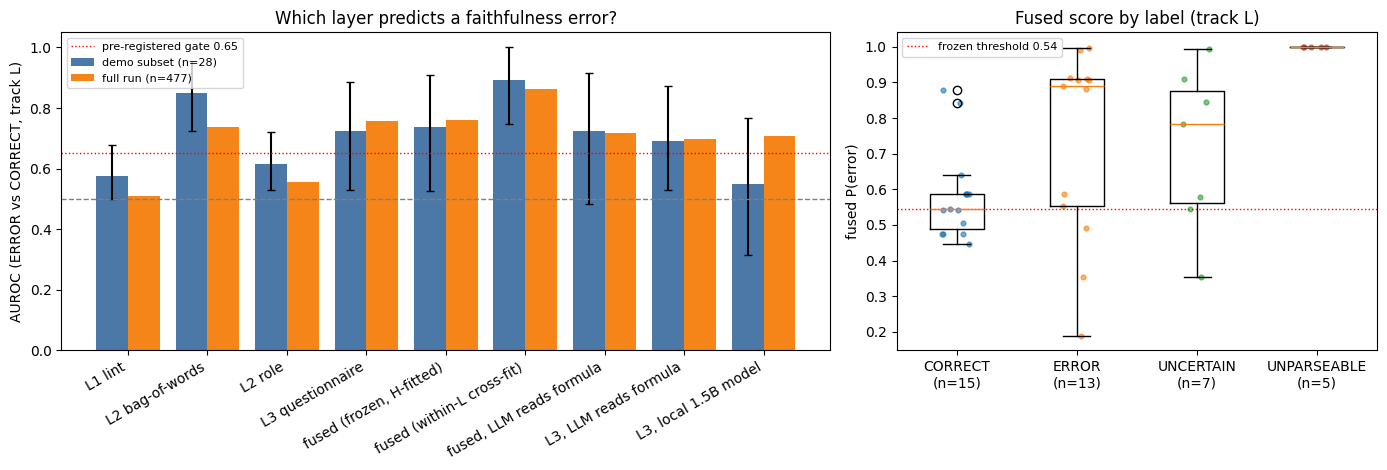

      label           system  p_fused  flag fired        code                                                                   text                                                 fol
UNPARSEABLE text-davinci-003    1.000     1 PARSE UNPARSEABLE     Plates that do not begin with the number 34 are not from Istanbul.                        ¬Begin(x, 34) → ¬Istanbul(x)
UNPARSEABLE    gpt-3.5-turbo    1.000     1 PARSE UNPARSEABLE                         Tom's license plate begins with the number 35.                             BeginWith(tomPlate, 35)
UNPARSEABLE text-davinci-003    1.000     1 PARSE UNPARSEABLE                                                  1984 is printed text.                                   PrintedText(1984)
UNPARSEABLE            gpt-4    1.000     1 PARSE UNPARSEABLE                         The monthly rent at the Olive Garden is $2000.                      MonthlyRent(2000, oliveGarden)
UNPARSEABLE    gpt-3.5-turbo    1.000     1 PARSE UNPARSEABLE              

In [23]:
M = json.loads((RES / "metrics.json").read_text())
FULL_RUN_AUROC = {  # primary set, full run (results/metrics.json of the original experiment)
    "l1_any": 0.508, "l2_bow": 0.737, "l2_role": 0.557, "l3_score": 0.756, "p_fused_H": 0.759,
    "p_fused_Lcf": 0.864, "cascade_llmformula": 0.716, "l3_score_llmformula": 0.697, "l3_score_local": 0.708}
NAMES = {"l1_any": "L1 lint", "l2_bow": "L2 bag-of-words", "l2_role": "L2 role", "l3_score": "L3 questionnaire",
         "p_fused_H": "fused (frozen, H-fitted)", "p_fused_Lcf": "fused (within-L cross-fit)",
         "cascade_llmformula": "fused, LLM reads formula", "l3_score_llmformula": "L3, LLM reads formula",
         "l3_score_local": "L3, local 1.5B model"}
ev = M["evaluations"]["primary_L_ERROR_vs_CORRECT"]
rows = []
for k, name in NAMES.items():
    v = ev["scores"].get(k)
    if not v:
        continue
    ci = v.get("AUROC_CI95_cluster") or [None, None]
    rows.append({"score": name, "AUROC (demo)": v.get("AUROC"), "CI95 low": ci[0], "CI95 high": ci[1],
                 "AUPRC (demo)": v.get("AUPRC"), "n scored": v.get("n_scored"), "AUROC (full run)": FULL_RUN_AUROC.get(k)})
tab = pd.DataFrame(rows)
print(f"primary set: n={ev['n']} (ERROR={ev['n_pos']}, CORRECT={ev['n'] - ev['n_pos']})")
print(tab.to_string(index=False))

print("\nGates (fused, primary set):")
for g, v in M["gates_fused_primary"].items():
    print(f"  {g:32s}", v if isinstance(v, str) else {kk: vv for kk, vv in v.items() if kk != "note"})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
t = tab.dropna(subset=["AUROC (demo)"])
x = np.arange(len(t))
lo = (t["AUROC (demo)"] - t["CI95 low"]).fillna(0).clip(lower=0)
hi = (t["CI95 high"] - t["AUROC (demo)"]).fillna(0).clip(lower=0)
ax.bar(x - 0.2, t["AUROC (demo)"], 0.4, yerr=[lo, hi], capsize=3, label=f"demo subset (n={ev['n']})", color="#4C78A8")
ax.bar(x + 0.2, t["AUROC (full run)"], 0.4, label="full run (n=477)", color="#F58518")
ax.axhline(0.5, color="grey", ls="--", lw=1)
ax.axhline(0.65, color="red", ls=":", lw=1, label="pre-registered gate 0.65")
ax.set_xticks(x); ax.set_xticklabels(t["score"], rotation=30, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("AUROC (ERROR vs CORRECT, track L)"); ax.legend(fontsize=8, loc="upper left")
ax.set_title("Which layer predicts a faithfulness error?")

# fused error probability by label on track L
per = [json.loads(l) for l in (RES / "per_item.jsonl").read_text().splitlines() if l.strip()]
Lr = [s for s in per if s["track"] == "L"]
ax = axes[1]
labs = ["CORRECT", "ERROR", "UNCERTAIN", "UNPARSEABLE"]
vals = [[s["p_fused_H"] for s in Lr if s["label"] == lab] for lab in labs]
ax.boxplot([v if v else [np.nan] for v in vals], tick_labels=[f"{lab}\n(n={len(v)})" for lab, v in zip(labs, vals)])
for i, v in enumerate(vals):
    ax.scatter(np.full(len(v), i + 1) + np.random.default_rng(0).uniform(-0.12, 0.12, len(v)), v, s=12, alpha=0.6)
thr = json.loads((RES / "calibration.json").read_text())["fused_threshold_noleak_OOF_10pctFA"]
ax.axhline(thr, color="red", ls=":", lw=1, label=f"frozen threshold {thr:.2f}")
ax.set_ylabel("fused P(error)"); ax.set_title("Fused score by label (track L)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# a few scored items: what fired and which error type the cascade names
show = pd.DataFrame([{"label": s["label"], "system": s["system"], "p_fused": round(s["p_fused_H"], 3),
                      "flag": s["fused_flag"], "fired": s["fired_layer"], "code": s["error_code"],
                      "text": s["text"][:70], "fol": s["candidate_fol"][:70]} for s in Lr])
print(show.sort_values("p_fused", ascending=False).head(15).to_string(index=False))
print(f"\nruntime of stages 4-7: {time.time() - t_start:.1f}s")